In [64]:
import os
import sys
import warnings
from pathlib import Path

import imagej
import matplotlib.pyplot as plt
import napari
import numpy as np
import pandas as pd
import scyjava as sj
import seaborn as sns
import tifffile as tiff

from cellpose import io, models
from imagej import Mode
from matplotlib.ticker import MaxNLocator
from skimage.filters import (
    gaussian,
    threshold_mean,
    threshold_otsu,
    threshold_triangle,
    threshold_yen,
 )
from skimage.measure import label
from tifffile import imread
from tqdm import tqdm

warnings.filterwarnings("ignore")

In [65]:
def cellpose_live_segmentation(
    stack,
    diameter=None,
    flow_threshold=0.4,
    cellprob_threshold=0.0,
    min_size=15,
    model_type="cyto3",
    gpu=True,
 ):
    """Segment brightfield stack with Cellpose."""
    if isinstance(stack, (str, Path)):
        stack = io.imread(stack)

    if stack.ndim == 2:
        stack = stack[np.newaxis, :, :]

    model = models.CellposeModel(gpu=gpu, model_type=model_type)

    if diameter is None:
        print("Auto-detecting cell diameter from first frame...")
        masks_first, _, _ = model.eval(
            stack[0, :, :],
            diameter=None,
            channels=[0, 0],
            flow_threshold=flow_threshold,
            cellprob_threshold=cellprob_threshold,
        )
        if masks_first.max() > 0:
            cell_areas = [np.sum(masks_first == i) for i in range(1, min(masks_first.max() + 1, 50))]
            median_area = np.median(cell_areas) if cell_areas else 700
            diameter = 2 * np.sqrt(median_area / np.pi)
        else:
            diameter = 30.0
        print(f"Estimated diameter: {diameter:.1f} pixels")

    masks_stack = np.zeros(stack.shape, dtype=np.uint16)
    print(f"Segmenting {stack.shape[0]} frames with Cellpose {model_type}...")
    for frame_idx in tqdm(range(stack.shape[0]), desc="Cellpose segmentation"):
        masks, _, _ = model.eval(
            stack[frame_idx, :, :],
            diameter=diameter,
            channels=[0, 0],
            flow_threshold=flow_threshold,
            cellprob_threshold=cellprob_threshold,
            min_size=min_size,
            resample=True,
        )
        masks_stack[frame_idx, :, :] = masks.astype(np.uint16)

    print("Segmentation complete.")
    return masks_stack[0] if masks_stack.shape[0] == 1 else masks_stack


def segment_fluorescence(red_stack, green_stack, blur_sigma=1.0, threshold_method="mean"):
    """Blur, threshold, and label red/green fluorescence stacks."""
    threshold_method = str(threshold_method).lower()
    threshold_functions = {
        "mean": threshold_mean,
        "yen": threshold_yen,
        "otsu": threshold_otsu,
        "triangle": threshold_triangle,
    }
    if threshold_method not in threshold_functions:
        raise ValueError(f"Unsupported threshold_method: {threshold_method}")

    red_blurred = np.stack([gaussian(frame, sigma=blur_sigma, preserve_range=True) for frame in red_stack], axis=0)
    green_blurred = np.stack([gaussian(frame, sigma=blur_sigma, preserve_range=True) for frame in green_stack], axis=0)

    threshold_fn = threshold_functions[threshold_method]
    red_thresh = threshold_fn(red_blurred)
    green_thresh = threshold_fn(green_blurred)

    red_positive = red_blurred > red_thresh
    green_positive = green_blurred > green_thresh

    red_positive_labels = np.stack([label(frame) for frame in red_positive], axis=0).astype(np.uint32)
    green_positive_labels = np.stack([label(frame) for frame in green_positive], axis=0).astype(np.uint32)

    return {
        "red_blurred": red_blurred,
        "green_blurred": green_blurred,
        "red_thresh": red_thresh,
        "green_thresh": green_thresh,
        "red_positive": red_positive,
        "green_positive": green_positive,
        "red_positive_labels": red_positive_labels,
        "green_positive_labels": green_positive_labels,
        "threshold_method": threshold_method,
        "blur_sigma": blur_sigma,
    }


def _configure_java_home():
    if os.environ.get("JAVA_HOME"):
        return os.environ["JAVA_HOME"]

    candidate_homes = []
    try:
        import jdk4py
        candidate_homes.append(str(jdk4py.JAVA_HOME))
    except Exception:
        pass
    candidate_homes.append(str(Path(sys.prefix) / "Library"))

    for home in candidate_homes:
        jvm_dll = Path(home) / "bin" / "server" / "jvm.dll"
        if jvm_dll.exists():
            os.environ["JAVA_HOME"] = str(home)
            os.environ["PATH"] = str(Path(home) / "bin") + os.pathsep + os.environ.get("PATH", "")
            return str(home)
    return None


def generate_trackmate_labels(
    masks_path,
    output_directory,
    target_channel=1,
    simplify_contours=False,
    initial_search_radius=30.0,
    search_radius=150.0,
    max_frame_gap=3,
    allow_track_splitting=False,
    allow_track_merging=False,
    debug=True,
 ):
    """Run TrackMate headless and return linked labels + tracks dataframe."""
    _configure_java_home()
    ij = imagej.init("sc.fiji:fiji", mode=Mode.HEADLESS, add_legacy=True)

    IJ = sj.jimport("ij.IJ")
    HashMap = sj.jimport("java.util.HashMap")
    Integer = sj.jimport("java.lang.Integer")
    Double = sj.jimport("java.lang.Double")

    Model = sj.jimport("fiji.plugin.trackmate.Model")
    Settings = sj.jimport("fiji.plugin.trackmate.Settings")
    TrackMate = sj.jimport("fiji.plugin.trackmate.TrackMate")
    Logger = sj.jimport("fiji.plugin.trackmate.Logger")
    LabelImageDetectorFactory = sj.jimport("fiji.plugin.trackmate.detection.LabelImageDetectorFactory")
    AdvancedKalmanTrackerFactory = sj.jimport("fiji.plugin.trackmate.tracking.kalman.AdvancedKalmanTrackerFactory")

    imp = IJ.openImage(str(masks_path))
    if imp is None:
        raise RuntimeError(f"Could not open image: {masks_path}")

    n_timepoints = int(imp.getNFrames())
    if n_timepoints <= 1:
        n_timepoints = int(imp.getStackSize())
    imp.setDimensions(1, 1, n_timepoints)
    imp.setOpenAsHyperStack(True)

    model = Model()
    model.setLogger(Logger.IJ_LOGGER)

    settings = Settings(imp)
    settings.detectorFactory = LabelImageDetectorFactory()
    detector_settings = HashMap()
    detector_settings.put("TARGET_CHANNEL", Integer.valueOf(int(target_channel)))
    detector_settings.put("SIMPLIFY_CONTOURS", bool(simplify_contours))
    settings.detectorSettings = detector_settings

    settings.trackerFactory = AdvancedKalmanTrackerFactory()
    tracker_settings = HashMap(settings.trackerFactory.getDefaultSettings())
    tracker_settings.put("KALMAN_SEARCH_RADIUS", Double.valueOf(float(search_radius)))
    tracker_settings.put("LINKING_MAX_DISTANCE", Double.valueOf(float(initial_search_radius)))
    tracker_settings.put("MAX_FRAME_GAP", Integer.valueOf(int(max_frame_gap)))
    tracker_settings.put("ALLOW_TRACK_SPLITTING", allow_track_splitting)
    tracker_settings.put("ALLOW_TRACK_MERGING", allow_track_merging)

    feature_penalties = HashMap()
    feature_penalties.put("POSITION_X", Double.valueOf(1.0))
    feature_penalties.put("POSITION_Y", Double.valueOf(1.0))
    feature_penalties.put("AREA", Double.valueOf(1.0))
    tracker_settings.put("LINKING_FEATURE_PENALTIES", feature_penalties)
    tracker_settings.put("GAP_CLOSING_FEATURE_PENALTIES", feature_penalties)

    settings.trackerSettings = tracker_settings
    settings.addAllAnalyzers()

    trackmate = TrackMate(model, settings)
    if not trackmate.checkInput():
        raise RuntimeError(f"TrackMate input error: {trackmate.getErrorMessage()}")
    if not trackmate.process():
        raise RuntimeError(f"TrackMate process error: {trackmate.getErrorMessage()}")

    tm = model.getTrackModel()
    track_ids = list(tm.trackIDs(True))
    rows = []
    for track_id in track_ids:
        track_spots = list(tm.trackSpots(track_id))
        track_spots.sort(key=lambda s: float(s.getFeature("FRAME")))
        for spot in track_spots:
            rows.append(
                {
                    "track_id": int(track_id),
                    "t": int(float(spot.getFeature("FRAME"))),
                    "y": float(spot.getFeature("POSITION_Y")),
                    "x": float(spot.getFeature("POSITION_X")),
                    "quality": float(spot.getFeature("QUALITY")),
                }
            )

    trackmate_tracks_df = pd.DataFrame(rows, columns=["track_id", "t", "y", "x", "quality"])
    tracks_csv = Path(output_directory) / "trackmate_tracks.csv"
    trackmate_tracks_df.to_csv(tracks_csv, index=False)

    masks_stack_local = tiff.imread(str(masks_path))
    linked_labels = np.zeros_like(masks_stack_local, dtype=np.uint32)
    linked_track_points = trackmate_tracks_df[["track_id", "t", "y", "x"]].to_numpy()
    n_t, n_y, n_x = masks_stack_local.shape

    for track_id, t, y, x in linked_track_points:
        ti = int(t)
        yi = int(np.clip(round(float(y)), 0, n_y - 1))
        xi = int(np.clip(round(float(x)), 0, n_x - 1))
        if ti < 0 or ti >= n_t:
            continue
        label_id = int(masks_stack_local[ti, yi, xi])
        if label_id <= 0:
            continue
        linked_labels[ti, masks_stack_local[ti] == label_id] = int(track_id) + 1

    linked_labels_path = Path(output_directory) / "linked_labels_trackmate.tiff"
    tiff.imwrite(str(linked_labels_path), linked_labels)

    if debug:
        print(f"Linked tracks: {len(track_ids)}")
        print(f"Saved TrackMate CSV: {tracks_csv.resolve()}")
        print(f"Saved linked labels TIFF: {linked_labels_path.resolve()}")
        if len(trackmate_tracks_df) > 0:
            display(trackmate_tracks_df.head(10))

    return {
        "ij": ij,
        "trackmate_tracks_df": trackmate_tracks_df,
        "linked_labels": linked_labels,
        "linked_labels_path": linked_labels_path,
        "tracks_csv": tracks_csv,
    }


def assign_persistent_fates(linked_labels, green_positive, red_positive):
    """Assign persistent per-cell fate using first positive color (green wins ties)."""
    if linked_labels.shape != green_positive.shape or linked_labels.shape != red_positive.shape:
        raise ValueError("Shape mismatch between linked labels and fluorescence masks.")

    n_frames = linked_labels.shape[0]
    label_ids = np.unique(linked_labels)
    label_ids = label_ids[label_ids > 0]

    rows = []
    for label_id in label_ids:
        first_green_frame = None
        first_red_frame = None

        for frame in range(n_frames):
            cell_mask = linked_labels[frame] == label_id
            if not np.any(cell_mask):
                continue
            if first_green_frame is None and np.any(green_positive[frame] & cell_mask):
                first_green_frame = frame
            if first_red_frame is None and np.any(red_positive[frame] & cell_mask):
                first_red_frame = frame
            if first_green_frame is not None and first_red_frame is not None:
                break

        if first_green_frame is None and first_red_frame is None:
            fate = "negative"
            first_positive_frame = np.nan
        elif first_green_frame is not None and (first_red_frame is None or first_green_frame <= first_red_frame):
            fate = "green"
            first_positive_frame = first_green_frame
        else:
            fate = "red"
            first_positive_frame = first_red_frame

        rows.append(
            {
                "label_id": int(label_id),
                "first_green_frame": first_green_frame if first_green_frame is not None else np.nan,
                "first_red_frame": first_red_frame if first_red_frame is not None else np.nan,
                "first_positive_frame": first_positive_frame,
                "fate": fate,
            }
        )

    assignments_df = pd.DataFrame(rows).sort_values(["fate", "first_positive_frame", "label_id"]).reset_index(drop=True)
    green_ids = assignments_df.loc[assignments_df["fate"] == "green", "label_id"].to_numpy(dtype=np.uint32)
    red_ids = assignments_df.loc[assignments_df["fate"] == "red", "label_id"].to_numpy(dtype=np.uint32)

    green_locked_labels = np.where(np.isin(linked_labels, green_ids), linked_labels, 0).astype(np.uint32)
    red_locked_labels = np.where(np.isin(linked_labels, red_ids), linked_labels, 0).astype(np.uint32)

    return assignments_df, green_locked_labels, red_locked_labels


def compute_persistent_percentages(assignments_df, n_frames):
    """Compute cumulative persistent green/red percentages over time."""
    n_tracked_cells = len(assignments_df)
    if n_tracked_cells == 0:
        raise ValueError("No tracked cells found in assignments_df.")

    green_pct, red_pct, total_pct = [], [], []
    for frame in range(n_frames):
        n_green = ((assignments_df["fate"] == "green") & (assignments_df["first_positive_frame"] <= frame)).sum()
        n_red = ((assignments_df["fate"] == "red") & (assignments_df["first_positive_frame"] <= frame)).sum()
        p_green = 100.0 * n_green / n_tracked_cells
        p_red = 100.0 * n_red / n_tracked_cells
        green_pct.append(p_green)
        red_pct.append(p_red)
        total_pct.append(p_green + p_red)

    return pd.DataFrame(
        {
            "frame": np.arange(n_frames),
            "green_pct": green_pct,
            "red_pct": red_pct,
            "total_positive_pct": total_pct,
        }
    )


def plot_persistent_percentages(summary_df, title="Persistent fluorescence-positive cells over time"):
    """Plot persistent percentage trajectories."""
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.lineplot(data=summary_df, x="frame", y="green_pct", color="green", label="Green (persistent)", ax=ax)
    sns.lineplot(data=summary_df, x="frame", y="red_pct", color="red", label="Red (persistent)", ax=ax)
    sns.lineplot(data=summary_df, x="frame", y="total_positive_pct", color="black", label="Total positive", ax=ax)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel("Frame")
    ax.set_ylabel("% Cells")
    ax.set_ylim(0, 100)
    ax.set_title(title)
    plt.tight_layout()
    return fig, ax


def launch_final_viewer(
    red_fluorescence_image,
    green_fluorescence_image,
    red_positive_labels,
    green_positive_labels,
    linked_labels,
    green_locked_labels,
    red_locked_labels,
    summary_df,
    brightfield_image=None,
    masks_stack=None,
    trackmate_tracks_df=None,
    show_brightfield=True,
    show_masks=True,
    show_linked_labels=True,
 ):
    """Launch final single Napari dashboard with all outputs."""
    _ = summary_df  # Explicitly required by pipeline validation.
    viewer = napari.Viewer(title="Cell Death Production Dashboard")

    if show_brightfield and brightfield_image is not None:
        viewer.add_image(brightfield_image, name="Brightfield", colormap="gray", blending="translucent", opacity=0.7)

    viewer.add_image(red_fluorescence_image, name="Red fluorescence", colormap="red", blending="additive")
    viewer.add_image(green_fluorescence_image, name="Green fluorescence", colormap="green", blending="additive")
    viewer.add_labels(red_positive_labels, name="Red positive regions", opacity=0.35)
    viewer.add_labels(green_positive_labels, name="Green positive regions", opacity=0.35)

    if show_linked_labels:
        viewer.add_labels(linked_labels, name="TrackMate linked labels", opacity=0.20)

    viewer.add_labels(green_locked_labels, name="Persistent green cells", opacity=0.60)
    viewer.add_labels(red_locked_labels, name="Persistent red cells", opacity=0.60)

    if show_masks and masks_stack is not None:
        viewer.add_labels(masks_stack.astype(np.uint32), name="Cellpose masks", opacity=0.15)

    if trackmate_tracks_df is not None and len(trackmate_tracks_df) > 0:
        points_data = trackmate_tracks_df[["t", "y", "x"]].to_numpy()
        viewer.add_points(points_data, name="TrackMate points", size=3, face_color="yellow", opacity=0.6)

    return viewer

In [66]:
output_directory = Path(r"e:\Marcus\cellpose_outputs")
output_directory.mkdir(parents=True, exist_ok=True)

PIPELINE = {
    "analysis_id": "fluorescence_linked_fates",
    "cellpose": {
        "diameter": None,
        "flow_threshold": 0.4,
        "cellprob_threshold": 0.0,
        "min_size": 15,
        "model_type": "cyto3",
        "gpu": True,
    },
    "fluorescence": {
        "blur_sigma": 1.0,
        "threshold_method": "mean",
    },
    "trackmate": {
        "target_channel": 1,
        "simplify_contours": False,
        "initial_search_radius": 30.0,
        "search_radius": 150.0,
        "max_frame_gap": 3,
        "allow_track_splitting": False,
        "allow_track_merging": False,
        "debug": True,
    },
    "viewer": {
        "show_brightfield": True,
        "show_masks": True,
        "show_linked_labels": True,
    },
}

print(f"Output directory ready: {output_directory.resolve()}")
print("Pipeline config initialized.")

Output directory ready: E:\Marcus\cellpose_outputs
Pipeline config initialized.


In [53]:
image = imread(r"e:\Marcus\combined_stack.tif")
brightfield_image = image[:, -1, :, :]
red_fluorescence_image = image[:, 0, :, :]
green_fluorescence_image = image[:, 1, :, :]


In [54]:
# Quick data check (no viewer here; final viewer is shown at the end)
print(f"Brightfield stack shape: {brightfield_image.shape}")
print(f"Red fluorescence stack shape: {red_fluorescence_image.shape}")
print(f"Green fluorescence stack shape: {green_fluorescence_image.shape}")

Brightfield stack shape: (25, 1040, 1408)
Red fluorescence stack shape: (25, 1040, 1408)
Green fluorescence stack shape: (25, 1040, 1408)


In [55]:
# Cellpose segmentation
cp = PIPELINE.get("cellpose", {}) if "PIPELINE" in globals() else {}
masks_stack = cellpose_live_segmentation(
    brightfield_image,
    diameter=cp.get("diameter", None),
    flow_threshold=cp.get("flow_threshold", 0.4),
    cellprob_threshold=cp.get("cellprob_threshold", 0.0),
    min_size=cp.get("min_size", 15),
    model_type=cp.get("model_type", "cyto3"),
    gpu=cp.get("gpu", True),
)

masks_path = output_directory / "masks_stack.tiff"
tiff.imwrite(str(masks_path), masks_stack.astype(np.uint16))
print(f"Saved masks stack to: {masks_path.resolve()}")

Auto-detecting cell diameter from first frame...
Estimated diameter: 48.1 pixels
Segmenting 25 frames with Cellpose cyto3...


Cellpose segmentation: 100%|██████████| 25/25 [00:27<00:00,  1.09s/it]


Segmentation complete.
Saved masks stack to: E:\Marcus\cellpose_outputs\masks_stack.tiff


In [56]:
# Generate TrackMate tracks + linked labels (headless Fiji/ImageJ)
trackmate_params = PIPELINE.get(
    "trackmate",
    {
        "target_channel": 1,
        "simplify_contours": False,
        "initial_search_radius": 30.0,
        "search_radius": 150.0,
        "max_frame_gap": 3,
        "allow_track_splitting": False,
        "allow_track_merging": False,
        "debug": True,
    },
)

masks_path = Path(output_directory) / "masks_stack.tiff"
if not masks_path.exists() and "masks_stack" in globals():
    tiff.imwrite(str(masks_path), np.asarray(masks_stack).astype(np.uint16))
    print(f"Re-saved masks stack to: {masks_path.resolve()}")

trackmate_output = generate_trackmate_labels(
    masks_path=masks_path,
    output_directory=output_directory,
    target_channel=trackmate_params.get("target_channel", 1),
    simplify_contours=trackmate_params.get("simplify_contours", False),
    initial_search_radius=trackmate_params.get("initial_search_radius", 30.0),
    search_radius=trackmate_params.get("search_radius", 150.0),
    max_frame_gap=trackmate_params.get("max_frame_gap", 3),
    allow_track_splitting=trackmate_params.get("allow_track_splitting", False),
    allow_track_merging=trackmate_params.get("allow_track_merging", False),
    debug=trackmate_params.get("debug", True),
)

trackmate_tracks_df = trackmate_output["trackmate_tracks_df"]
linked_labels = trackmate_output["linked_labels"]
linked_labels_path = trackmate_output["linked_labels_path"]
tracks_csv = trackmate_output["tracks_csv"]

Linked tracks: 282
Saved TrackMate CSV: E:\Marcus\cellpose_outputs\trackmate_tracks.csv
Saved linked labels TIFF: E:\Marcus\cellpose_outputs\linked_labels_trackmate.tiff


,track_id,t,y,x,quality
0,0,0,190.667204,1319.284448,1241.0
1,0,1,183.596835,1318.276582,1580.0
2,0,2,174.680985,1315.488214,1909.0
3,0,3,169.767582,1302.557692,1820.0
4,0,4,172.245902,1315.774078,1952.0
5,0,5,189.148430,1340.075988,1974.0
6,0,6,207.241501,1353.444314,2559.0
7,0,7,230.402733,1347.525699,1537.0
8,0,8,255.690821,1352.036012,2277.0
9,0,9,254.663421,1357.449235,2876.0


In [57]:
# TrackMate output validation (no viewer here; final viewer is shown at the end)
if "trackmate_tracks_df" not in globals():
    raise ValueError("Run Cell 7 (TrackMate headless) first.")

linked_labels_path = Path(output_directory) / "linked_labels_trackmate.tiff"
if not linked_labels_path.exists():
    raise ValueError(
        f"Linked labels not found at: {linked_labels_path}. Run Cell 7 first to generate it."
    )

linked_labels = tiff.imread(str(linked_labels_path))
print(f"Track points: {len(trackmate_tracks_df)}")
print(f"Linked labels shape: {linked_labels.shape}")
display(trackmate_tracks_df.head(10))

Track points: 4635
Linked labels shape: (25, 1040, 1408)


,track_id,t,y,x,quality
0,0,0,190.667204,1319.284448,1241.0
1,0,1,183.596835,1318.276582,1580.0
2,0,2,174.680985,1315.488214,1909.0
3,0,3,169.767582,1302.557692,1820.0
4,0,4,172.245902,1315.774078,1952.0
5,0,5,189.148430,1340.075988,1974.0
6,0,6,207.241501,1353.444314,2559.0
7,0,7,230.402733,1347.525699,1537.0
8,0,8,255.690821,1352.036012,2277.0
9,0,9,254.663421,1357.449235,2876.0


In [59]:
# Fluorescence segmentation (red + green)
if "PIPELINE" not in globals():
    PIPELINE = {"fluorescence": {"blur_sigma": 1.0, "threshold_method": "mean"}}

fluorescence_params = PIPELINE.get("fluorescence", {})
fluorescence_output = segment_fluorescence(
    red_stack=red_fluorescence_image,
    green_stack=green_fluorescence_image,
    blur_sigma=float(fluorescence_params.get("blur_sigma", 1.0)),
    threshold_method=str(fluorescence_params.get("threshold_method", "mean")),
)

red_blurred = fluorescence_output["red_blurred"]
green_blurred = fluorescence_output["green_blurred"]
red_thresh = fluorescence_output["red_thresh"]
green_thresh = fluorescence_output["green_thresh"]
red_positive = fluorescence_output["red_positive"]
green_positive = fluorescence_output["green_positive"]
red_positive_labels = fluorescence_output["red_positive_labels"]
green_positive_labels = fluorescence_output["green_positive_labels"]

print(f"Gaussian sigma: {fluorescence_output['blur_sigma']}")
print(f"Threshold method: {fluorescence_output['threshold_method']}")
print(f"Red threshold: {red_thresh:.3f}")
print(f"Green threshold: {green_thresh:.3f}")
print("Fluorescence-positive segmentation complete.")

Gaussian sigma: 1.0
Threshold method: mean
Red threshold: 8.365
Green threshold: 1.196
Fluorescence-positive segmentation complete.


In [60]:
# Persistent fate assignment using linked labels + fluorescence positives
if "linked_labels" not in globals():
    linked_labels_path = Path(output_directory) / "linked_labels_trackmate.tiff"
    if not linked_labels_path.exists():
        raise ValueError("Run Cell 7 first to generate linked labels.")
    linked_labels = tiff.imread(str(linked_labels_path))

assignments_df, green_locked_labels, red_locked_labels = assign_persistent_fates(
    linked_labels=linked_labels,
    green_positive=green_positive,
    red_positive=red_positive,
)

analysis_id = str(PIPELINE.get("analysis_id", "fluorescence_linked_fates")) if "PIPELINE" in globals() else "fluorescence_linked_fates"
assignments_csv = Path(output_directory) / f"{analysis_id}_assignments.csv"
assignments_df.to_csv(assignments_csv, index=False)

print(f"Saved assignments: {assignments_csv.resolve()}")
print(assignments_df["fate"].value_counts(dropna=False))
display(assignments_df.head(20))

Saved assignments: E:\Marcus\cellpose_outputs\fluorescence_linked_fates_assignments.csv
fate
green       211
red          47
negative     24
Name: count, dtype: int64


,label_id,first_green_frame,first_red_frame,first_positive_frame,fate
0,14,0.0,11.0,0.0,green
1,36,0.0,5.0,0.0,green
2,106,0.0,11.0,0.0,green
3,91,1.0,3.0,1.0,green
4,142,1.0,1.0,1.0,green
5,122,2.0,3.0,2.0,green
6,7,3.0,6.0,3.0,green
7,11,3.0,10.0,3.0,green
8,29,3.0,NaN,3.0,green
9,78,3.0,10.0,3.0,green


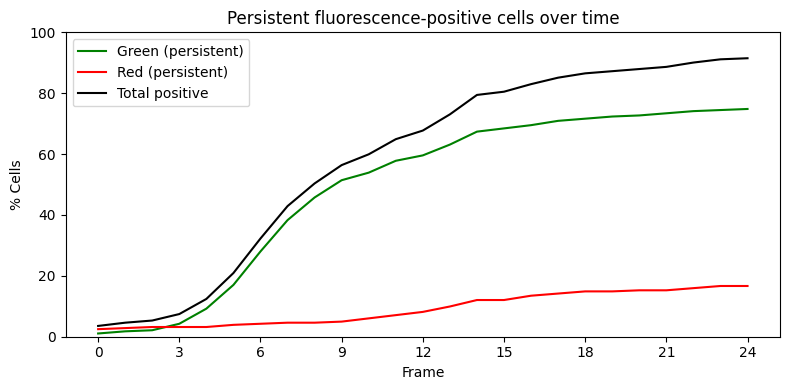

Saved summary CSV: E:\Marcus\cellpose_outputs\fluorescence_linked_fates_percentages_over_time.csv
Saved plot PDF: E:\Marcus\cellpose_outputs\fluorescence_linked_fates_percentages_over_time.pdf


,frame,green_pct,red_pct,total_positive_pct
0,0,1.063830,2.482270,3.546099
1,1,1.773050,2.836879,4.609929
2,2,2.127660,3.191489,5.319149
3,3,4.255319,3.191489,7.446809
4,4,9.219858,3.191489,12.411348
5,5,17.021277,3.900709,20.921986
6,6,28.014184,4.255319,32.269504
7,7,38.297872,4.609929,42.907801
8,8,45.744681,4.609929,50.354610
9,9,51.418440,4.964539,56.382979


In [61]:
# Persistent percentages over time + plot export
if "assignments_df" not in globals():
    raise ValueError("Run Cell 12 first to generate assignments_df.")

n_frames = linked_labels.shape[0]
summary_df = compute_persistent_percentages(assignments_df=assignments_df, n_frames=n_frames)
fig, ax = plot_persistent_percentages(summary_df)

analysis_id = str(PIPELINE.get("analysis_id", "fluorescence_linked_fates")) if "PIPELINE" in globals() else "fluorescence_linked_fates"
summary_csv = Path(output_directory) / f"{analysis_id}_percentages_over_time.csv"
plot_pdf = Path(output_directory) / f"{analysis_id}_percentages_over_time.pdf"
summary_df.to_csv(summary_csv, index=False)
fig.savefig(plot_pdf, bbox_inches="tight", transparent=False)

plt.show()
print(f"Saved summary CSV: {summary_csv.resolve()}")
print(f"Saved plot PDF: {plot_pdf.resolve()}")
display(summary_df.head(10))

In [67]:
# Final single Napari dashboard
required_vars = [
    "red_fluorescence_image",
    "green_fluorescence_image",
    "red_positive_labels",
    "green_positive_labels",
    "linked_labels",
    "green_locked_labels",
    "red_locked_labels",
    "summary_df",
]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise ValueError(f"Missing required variables: {missing}. Run Cells 1-13 first.")

viewer_cfg = PIPELINE.get("viewer", {}) if "PIPELINE" in globals() else {}
viewer = launch_final_viewer(
    red_fluorescence_image=red_fluorescence_image,
    green_fluorescence_image=green_fluorescence_image,
    red_positive_labels=red_positive_labels,
    green_positive_labels=green_positive_labels,
    linked_labels=linked_labels,
    green_locked_labels=green_locked_labels,
    red_locked_labels=red_locked_labels,
    summary_df=summary_df,
    brightfield_image=brightfield_image if "brightfield_image" in globals() else None,
    masks_stack=masks_stack if "masks_stack" in globals() else None,
    trackmate_tracks_df=trackmate_tracks_df if "trackmate_tracks_df" in globals() else None,
    show_brightfield=bool(viewer_cfg.get("show_brightfield", True)),
    show_masks=bool(viewer_cfg.get("show_masks", True)),
    show_linked_labels=bool(viewer_cfg.get("show_linked_labels", True)),
)

print("Final viewer ready.")
print("Saved outputs in output_directory include:")
print("- *_assignments.csv")
print("- *_percentages_over_time.csv")
print("- *_percentages_over_time.pdf")
napari.run()

Final viewer ready.
Saved outputs in output_directory include:
- *_assignments.csv
- *_percentages_over_time.csv
- *_percentages_over_time.pdf
